In [1]:
import keras
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# !wget -q https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f283/download/420938113-1629960298/mvtec_anomaly_detection.tar.xz

In [ ]:
# !tar -xf mvtec_anomaly_detection.tar.xz
# !rm mvtec_anomaly_detection.tar.xz
# !rm license.txt
# !rm readme.txt

In [24]:
!ls bottle/test/

broken_large  broken_small  contamination  good


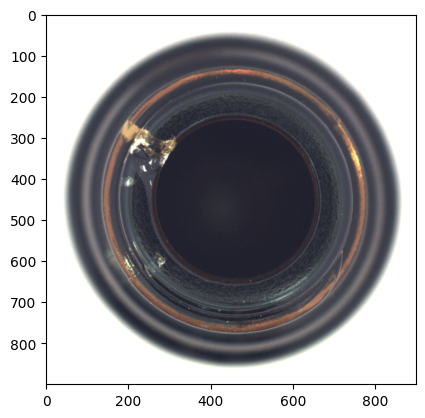

In [25]:
img = plt.imread('bottle/test/broken_small/001.png')
plt.imshow(img)
plt.show()

In [ ]:
# ============================================================
# 1) Multi-scale CNN Encoder (Frozen ResNet50 backbone)
# ============================================================
class ResNet50MultiScaleEncoder(keras.Model):
    """
    Returns multi-scale feature maps from ResNet50:
      - conv2_block3_out (fine)
      - conv3_block4_out (mid)
      - conv4_block6_out (coarse)
    """
    def __init__(self, pretrained=True, freeze=True, name="resnet50_multiscale_encoder"):
        super().__init__(name=name)

        weights = "imagenet" if pretrained else None
        base = keras.applications.ResNet50(
            include_top=False,
            weights=weights
        )

        # Pick intermediate layers (good for localization)
        layer_names = [
            "conv2_block3_out",  # finer
            "conv3_block4_out",  # mid
            "conv4_block6_out",  # coarser
        ]
        outputs = [base.get_layer(n).output for n in layer_names]
        self.feature_extractor = keras.Model(inputs=base.input, outputs=outputs, name="resnet50_features")

        if freeze:
            self.feature_extractor.trainable = False

    def call(self, x, training=False):
        # x should be preprocessed with keras.applications.resnet.preprocess_input
        f1, f2, f3 = self.feature_extractor(x, training=training)
        return f1, f2, f3

In [ ]:
# ============================================================
# 2) Patch Embedding Head
#    - fuse multi-scale features into one dense embedding map
# ============================================================
class PatchEmbeddingHead(keras.Model):
    """
    Fuses multi-scale features and outputs a compact embedding per spatial patch.
    """
    def __init__(self, hidden_dim=256, embed_dim=128, name="patch_embedding_head"):
        super().__init__(name=name)

        self.conv1 = layers.Conv2D(hidden_dim, kernel_size=1, use_bias=False)
        self.bn1 = layers.BatchNormalization()
        self.act1 = layers.ReLU()

        self.conv2 = layers.Conv2D(embed_dim, kernel_size=1, use_bias=False)
        self.bn2 = layers.BatchNormalization()

    def call(self, f1, f2, f3, training=False):
        """
        Align all features to f2 resolution (middle scale), then concat.
        """
        target_h = tf.shape(f2)[1]
        target_w = tf.shape(f2)[2]

        f1_resized = tf.image.resize(f1, size=(target_h, target_w), method="bilinear")
        f3_resized = tf.image.resize(f3, size=(target_h, target_w), method="bilinear")

        fused = tf.concat([f1_resized, f2, f3_resized], axis=-1)  # [B, H, W, C_total]

        x = self.conv1(fused)
        x = self.bn1(x, training=training)
        x = self.act1(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        # L2 normalize on channel axis so cosine similarity works well
        x = tf.math.l2_normalize(x, axis=-1)
        return x  # [B, H, W, embed_dim]


In [ ]:
# ============================================================
# 3) Main MVTec-style Patch Anomaly Model (TensorFlow)
#    - build memory bank from NORMAL train images
#    - infer anomaly map + image score on test images
# ============================================================
class MVTecPatchAnomalyTF(keras.Model):
    """
    Feature-based anomaly detection model:
      - Extract dense patch embeddings
      - Compare test patch embeddings with memory bank (normal patches)
      - Nearest-neighbor cosine distance => anomaly score / heatmap
    """
    def __init__(self, embed_dim=128, pretrained_backbone=True, freeze_backbone=True, name="mvtec_patch_anomaly_tf"):
        super().__init__(name=name)

        self.encoder = ResNet50MultiScaleEncoder(
            pretrained=pretrained_backbone,
            freeze=freeze_backbone
        )
        self.head = PatchEmbeddingHead(embed_dim=embed_dim)

        # Memory bank: Tensor [N_patches, embed_dim], filled later
        self.memory_bank = None

    def call(self, x, training=False):
        """
        Returns normalized dense patch embedding map: [B, H', W', C]
        """
        f1, f2, f3 = self.encoder(x, training=training)
        emb_map = self.head(f1, f2, f3, training=training)
        return emb_map

    def forward_features(self, x, training=False):
        return self.call(x, training=training)

    @tf.function
    def _flatten_patches(self, emb_map):
        """
        emb_map: [B, H, W, C]
        returns patches: [B*H*W, C]
        """
        shape = tf.shape(emb_map)
        b, h, w, c = shape[0], shape[1], shape[2], shape[3]
        patches = tf.reshape(emb_map, [b * h * w, c])
        return patches

    def fit_memory_bank(self, train_dataset, max_patches=50000, verbose=True):
        """
        Build memory bank using NORMAL training images only.

        train_dataset can yield:
          - images
          - (images, labels)  # labels ignored
        IMPORTANT:
          - Input images should already be preprocessed for ResNet50
          - Recommended batch shape: [B, H, W, 3]
        """
        patch_list = []
        total_patches = 0

        for batch_idx, batch in enumerate(train_dataset):
            # Support both `images` and `(images, labels)`
            if isinstance(batch, (tuple, list)):
                x = batch[0]
            else:
                x = batch

            emb_map = self.forward_features(x, training=False)  # [B, H', W', C]
            patches = self._flatten_patches(emb_map)            # [B*H'*W', C]
            patch_list.append(patches)
            total_patches += int(patches.shape[0]) if patches.shape[0] is not None else int(tf.shape(patches)[0])

            if verbose and (batch_idx + 1) % 10 == 0:
                print(f"[fit_memory_bank] processed batches: {batch_idx + 1}, collected patches: {total_patches}")

        all_patches = tf.concat(patch_list, axis=0)  # [N, C]
        all_patches = tf.math.l2_normalize(all_patches, axis=-1)

        # Optional random subsampling to reduce memory/computation
        n = tf.shape(all_patches)[0]
        if tf.greater(n, max_patches):
            idx = tf.random.shuffle(tf.range(n))[:max_patches]
            all_patches = tf.gather(all_patches, idx)

        self.memory_bank = all_patches  # [N, C]

        if verbose:
            print(f"[fit_memory_bank] final memory bank shape: {self.memory_bank.shape}")

    def _nearest_neighbor_distance(self, query_patches, chunk_size=4096):
        """
        Compute nearest-neighbor cosine distance to memory bank.

        query_patches: [Q, C] normalized
        memory_bank:   [N, C] normalized

        cosine distance = 1 - max cosine similarity
        """
        if self.memory_bank is None:
            raise RuntimeError("Memory bank is empty. Call fit_memory_bank(...) first.")

        query_patches = tf.math.l2_normalize(query_patches, axis=-1)
        memory = self.memory_bank  # [N, C]

        q_count = tf.shape(query_patches)[0]
        distances = []

        # Python loop is okay in eager mode for inference utility
        start = 0
        while start < int(q_count):
            end = min(start + chunk_size, int(q_count))
            q = query_patches[start:end]          # [q, C]

            # similarity matrix: [q, N]
            sim = tf.matmul(q, memory, transpose_b=True)

            # nearest normal patch => maximum cosine similarity
            max_sim = tf.reduce_max(sim, axis=1)  # [q]
            dist = 1.0 - max_sim                  # [q]
            distances.append(dist)

            start = end

        return tf.concat(distances, axis=0)       # [Q]

    def predict_anomaly(self, x, topk_ratio=0.01, upsample_to_input=True):
        """
        Predict anomaly heatmap + image-level anomaly score.

        Args:
            x: [B, H, W, 3] (preprocessed)
            topk_ratio: image score = mean of top-k highest anomaly values
            upsample_to_input: upsample heatmap to input HxW

        Returns:
            {
              "anomaly_map": [B, H', W', 1] or [B, H, W, 1],
              "image_score": [B]
            }
        """
        if self.memory_bank is None:
            raise RuntimeError("Memory bank is empty. Call fit_memory_bank(...) first.")

        emb_map = self.forward_features(x, training=False)  # [B, H', W', C]
        b = tf.shape(emb_map)[0]
        h = tf.shape(emb_map)[1]
        w = tf.shape(emb_map)[2]
        c = tf.shape(emb_map)[3]

        patches = tf.reshape(emb_map, [b * h * w, c])       # [B*H'*W', C]
        dist = self._nearest_neighbor_distance(patches)     # [B*H'*W']

        anomaly_map = tf.reshape(dist, [b, h, w, 1])        # [B, H', W', 1]

        if upsample_to_input:
            input_h = tf.shape(x)[1]
            input_w = tf.shape(x)[2]
            anomaly_map_up = tf.image.resize(anomaly_map, size=(input_h, input_w), method="bilinear")
        else:
            anomaly_map_up = anomaly_map

        # Image-level score: mean of top-k anomaly values
        flat = tf.reshape(anomaly_map_up, [b, -1])          # [B, H*W]
        total = tf.shape(flat)[1]
        k = tf.maximum(1, tf.cast(tf.cast(total, tf.float32) * topk_ratio, tf.int32))

        # top_k returns highest values
        topk_vals = tf.math.top_k(flat, k=k, sorted=False).values
        image_score = tf.reduce_mean(topk_vals, axis=1)     # [B]

        return {
            "anomaly_map": anomaly_map_up,
            "image_score": image_score
        }

    def predict_good_bad(self, x, threshold):
        """
        threshold-based final decision:
          score >= threshold -> defective (1)
          score <  threshold -> good (0)
        """
        out = self.predict_anomaly(x)
        score = out["image_score"]
        pred = tf.cast(score >= threshold, tf.int32)
        out["pred_label"] = pred
        return out


In [ ]:
# ============================================================
# 4) Threshold estimation utility (normal validation scores)
# ============================================================
def estimate_threshold_from_normal_scores(model, val_dataset, percentile=99.5):
    """
    Estimate threshold from NORMAL validation images.
    Example:
      percentile=99.5 means top 0.5% of normal scores are treated as defect.
    """
    scores = []
    for batch in val_dataset:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        out = model.predict_anomaly(x)
        scores.append(out["image_score"])

    scores = tf.concat(scores, axis=0)  # [N]
    scores_sorted = tf.sort(scores)
    n = tf.shape(scores_sorted)[0]

    # percentile index (clamped)
    idx = tf.cast(tf.round((percentile / 100.0) * tf.cast(n - 1, tf.float32)), tf.int32)
    idx = tf.clip_by_value(idx, 0, n - 1)

    threshold = float(scores_sorted[idx].numpy())
    return threshold

In [ ]:
# ============================================================
# 5) Example usage (architecture flow only)
# ============================================================
if __name__ == "__main__":
    # Dummy example inputs just to build the model
    # Real input images should be preprocessed using:
    # keras.applications.resnet.preprocess_input(...)
    x_dummy = tf.random.uniform([2, 256, 256, 3], minval=0, maxval=255, dtype=tf.float32)
    x_dummy = keras.applications.resnet.preprocess_input(x_dummy)

    model = MVTecPatchAnomalyTF(embed_dim=128)

    # Build layers by calling once
    _ = model.forward_features(x_dummy, training=False)

    print("TensorFlow MVTec Patch Anomaly Architecture ready.")

    # --------------------------------------------------------
    # STEP A: Build memory bank from NORMAL train images only
    # model.fit_memory_bank(train_dataset_normal, max_patches=50000)
    # --------------------------------------------------------

    # --------------------------------------------------------
    # STEP B: Estimate threshold from NORMAL validation images (optional)
    # threshold = estimate_threshold_from_normal_scores(model, val_dataset_normal, percentile=99.5)
    # print("Estimated threshold:", threshold)
    # --------------------------------------------------------

    # --------------------------------------------------------
    # STEP C: Inference on test batch
    # out = model.predict_anomaly(x_test_preprocessed)
    # anomaly_map = out["anomaly_map"]   # [B,H,W,1]
    # image_score = out["image_score"]   # [B]
    #
    # out2 = model.predict_good_bad(x_test_preprocessed, threshold=threshold)
    # pred_label = out2["pred_label"]    # 0=good, 1=defective
    # --------------------------------------------------------